In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcZG91Z3VccHl0aG9uLmdpdGh1Yi5pbw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\importlib\\_bootstrap.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\importlib\\_bootstrap_external.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\zipimport.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\codecs.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\aliases.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\__init__.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\encodings\\utf_8.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\abc.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\io.py": 1755196382.0, "C:\\Users\\dougu\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\stat.

In [2]:
import pandas as pd

# Definindo os dicionários para conversão de tipos e mapeamento de valores
tipos_converter = {
    'sex': 'object',
    'chest-pain': 'object',
    'heart-disease': 'object',
    'thal' : 'object',
}

mapeamento_sex = {
    0.0: 'feminino',
    1.0: 'masculino'
}

mapeamento_chest_pain = {
    1.0: 'angina típica',
    2.0: 'angina atípica',
    3.0: 'dor não anginosa',
    4.0: 'assintomática'
}

mapeamento_thal = {
    3.0: 'normal',
    6.0: 'defeito fixo',
    7.0: 'defeito reversível'
}

mapeamento_heart_disease = {
    1: 'não',
    2: 'sim'
}

# importando base de dados
base = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/statlog_heart.csv")[['sex', 'chest-pain', 'thal', 'heart-disease']]

# alterando o tipo de algumas colunas de acordo com o dicionário
base = base.astype(tipos_converter)

# alterando os valores de acordo com os dicionários
base['sex'] = base['sex'].map(mapeamento_sex)
base['chest-pain'] = base['chest-pain'].map(mapeamento_chest_pain)
base['heart-disease'] = base['heart-disease'].map(mapeamento_heart_disease)
base['thal'] = base['thal'].map(mapeamento_thal)

# filtrando a base para considerar apenas os tipos de dor torácica relevantes
base = base[(base['chest-pain'] == 'angina típica') |
                         (base['chest-pain'] == 'angina atípica')]

base.head()

,sex,chest-pain,thal,heart-disease
2,masculino,angina atípica,defeito reversível,sim
4,feminino,angina atípica,normal,não
13,masculino,angina típica,normal,sim
18,masculino,angina típica,normal,não
19,masculino,angina típica,defeito reversível,não


In [3]:
# Realizando contagem do número de ocorrências de cada sexo
base['sex'].value_counts()

sex
masculino    42
feminino     20
Name: count, dtype: int64

In [4]:
# Verificando quantos indivíduos possuem doença cardíaca de acordo com o sexo
pd.crosstab(base['sex'], base['heart-disease'])

heart-disease,não,sim
sex,,
feminino,19,1
masculino,31,11


In [5]:
0.38 * (42 / 62) + 0.095 * (20 / 62)

0.2880645161290322

In [6]:
# Verificando quantos indivíduos possuem doença cardíaca de acordo com o tipo de dor torácica
base.groupby('chest-pain')['heart-disease'].value_counts().sort_index()

chest-pain      heart-disease
angina atípica  não              35
                sim               7
angina típica   não              15
                sim               5
Name: count, dtype: int64

In [7]:
base.groupby(['thal'])['heart-disease'].value_counts().sort_index()

thal                heart-disease
defeito fixo        não               3
                    sim               1
defeito reversível  não               7
                    sim               6
normal              não              40
                    sim               5
Name: count, dtype: int64

In [8]:
# grupo de indivíduos "thal = reversível sim"
grupo_reversivel_sim = base[(base['thal'] == 'defeito reversível') & (base['heart-disease'] == 'sim')]

grupo_reversivel_sim.head()

,sex,chest-pain,thal,heart-disease
2,masculino,angina atípica,defeito reversível,sim
59,masculino,angina atípica,defeito reversível,sim
144,masculino,angina atípica,defeito reversível,sim
160,masculino,angina típica,defeito reversível,sim
210,masculino,angina típica,defeito reversível,sim


In [9]:
# grupo de indivíduos "thal = reversível não"
grupo_reversivel_nao = base[(base['thal'] == 'defeito reversível') & (base['heart-disease'] == 'não')]

grupo_reversivel_nao.head()

,sex,chest-pain,thal,heart-disease
19,masculino,angina típica,defeito reversível,não
43,masculino,angina atípica,defeito reversível,não
87,masculino,angina típica,defeito reversível,não
158,masculino,angina típica,defeito reversível,não
192,masculino,angina atípica,defeito reversível,não


In [10]:
vendas = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/advertising.csv")

vendas

,TV,radio,newspaper,sales
0,200.0,2.6,21.2,10.6
1,66.1,5.8,24.2,8.6
2,215.0,24.0,4.0,17.4
3,23.8,35.1,65.9,9.2
4,97.5,7.6,7.2,9.7
5,204.0,32.9,46.0,19.0
6,195.0,47.7,52.9,22.4
7,67.8,36.6,114.0,12.5
8,281.0,39.6,55.8,24.4
9,69.2,20.5,18.3,11.3


<Axes: xlabel='TV', ylabel='sales'>

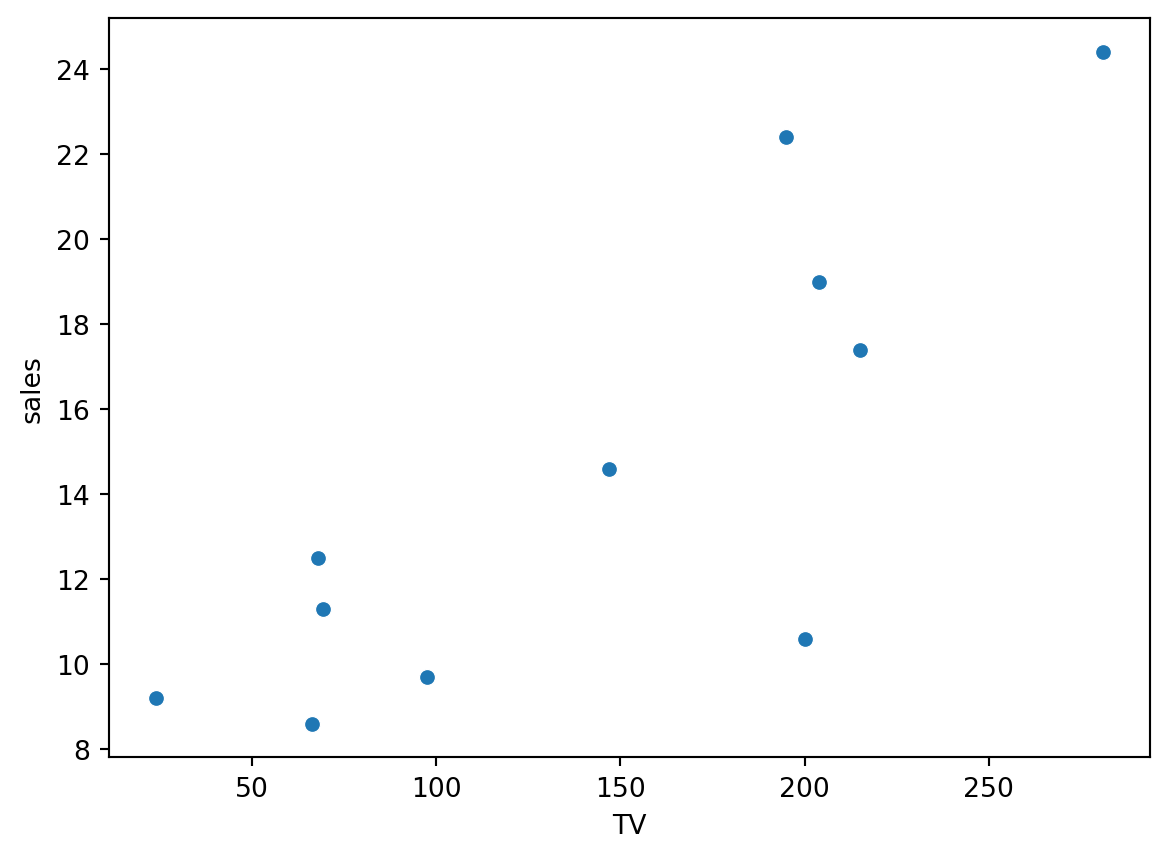

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=vendas, x='TV', y='sales')

In [12]:
import statistics as stat

ordenados = vendas['TV'].sort_values(ascending=True)

stat.mean(ordenados[0:2])

44.949999999999996

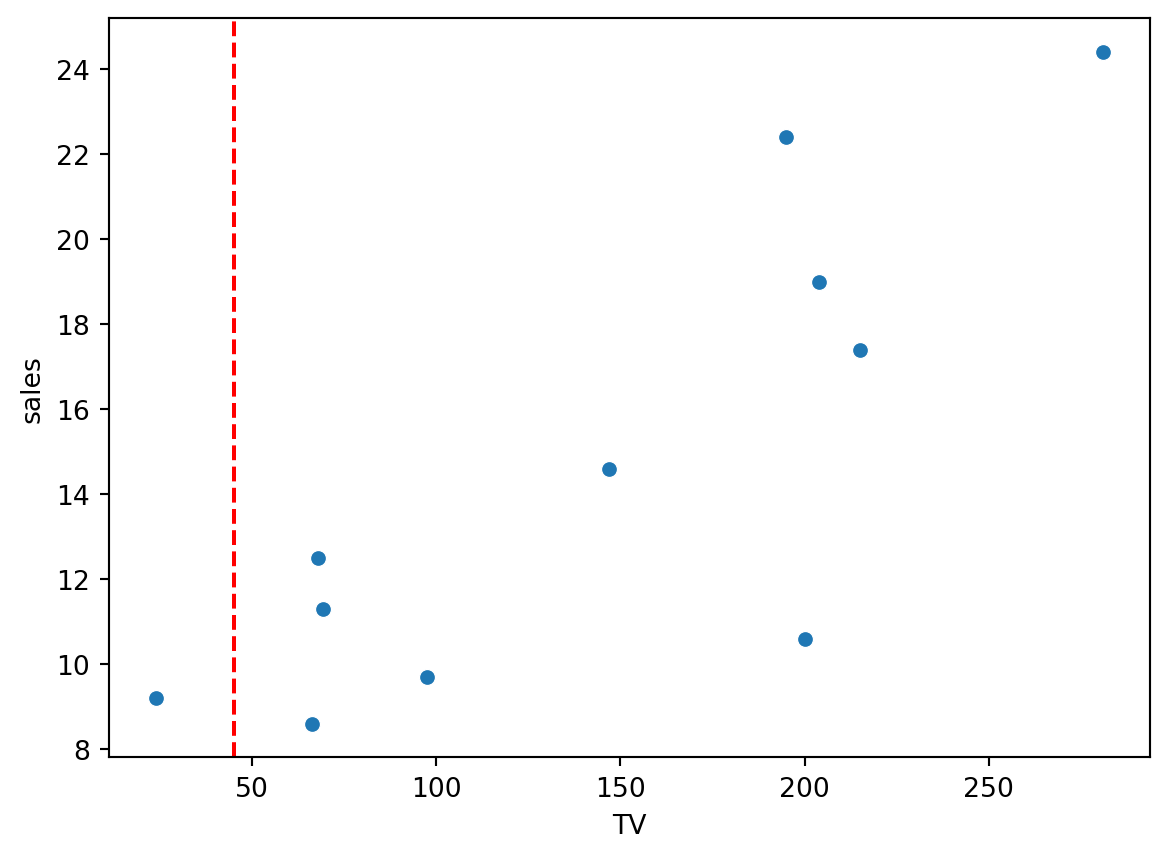

In [13]:
sns.scatterplot(data=vendas, x='TV', y='sales')
plt.axvline(x=44.95, color='red', linestyle='--', label='Média das duas menores vendas')

In [14]:
stat.mean(vendas[vendas['TV'] > 44.95]['sales'])

15.049999999999999

In [15]:
stat.mean(ordenados[1:3])

66.94999999999999

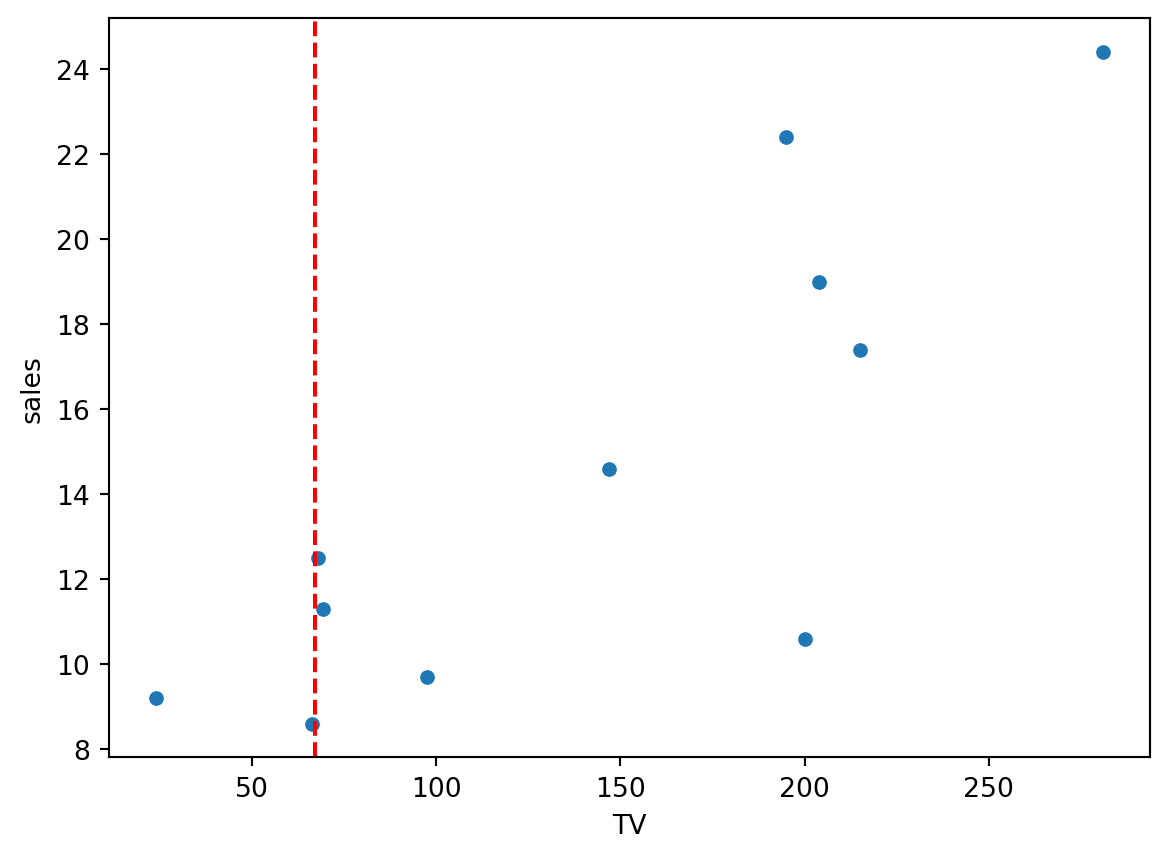

In [16]:
sns.scatterplot(data=vendas, x='TV', y='sales')
plt.axvline(x=66.95, color='red', linestyle='--', label='Média das duas menores vendas')

In [17]:
# Importando as bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

college = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/College.csv").drop(columns=['Unnamed: 0'])

X = college.drop(columns=['Private'])
y = college['Private']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
# Treinando o modelo
# max_depth é um hiperparâmetro que limita a profundidade da árvore para evitar overfitting
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Fazendo previsões e avaliando o modelo
accuracy = clf.score(X_test, y_test)
print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.88


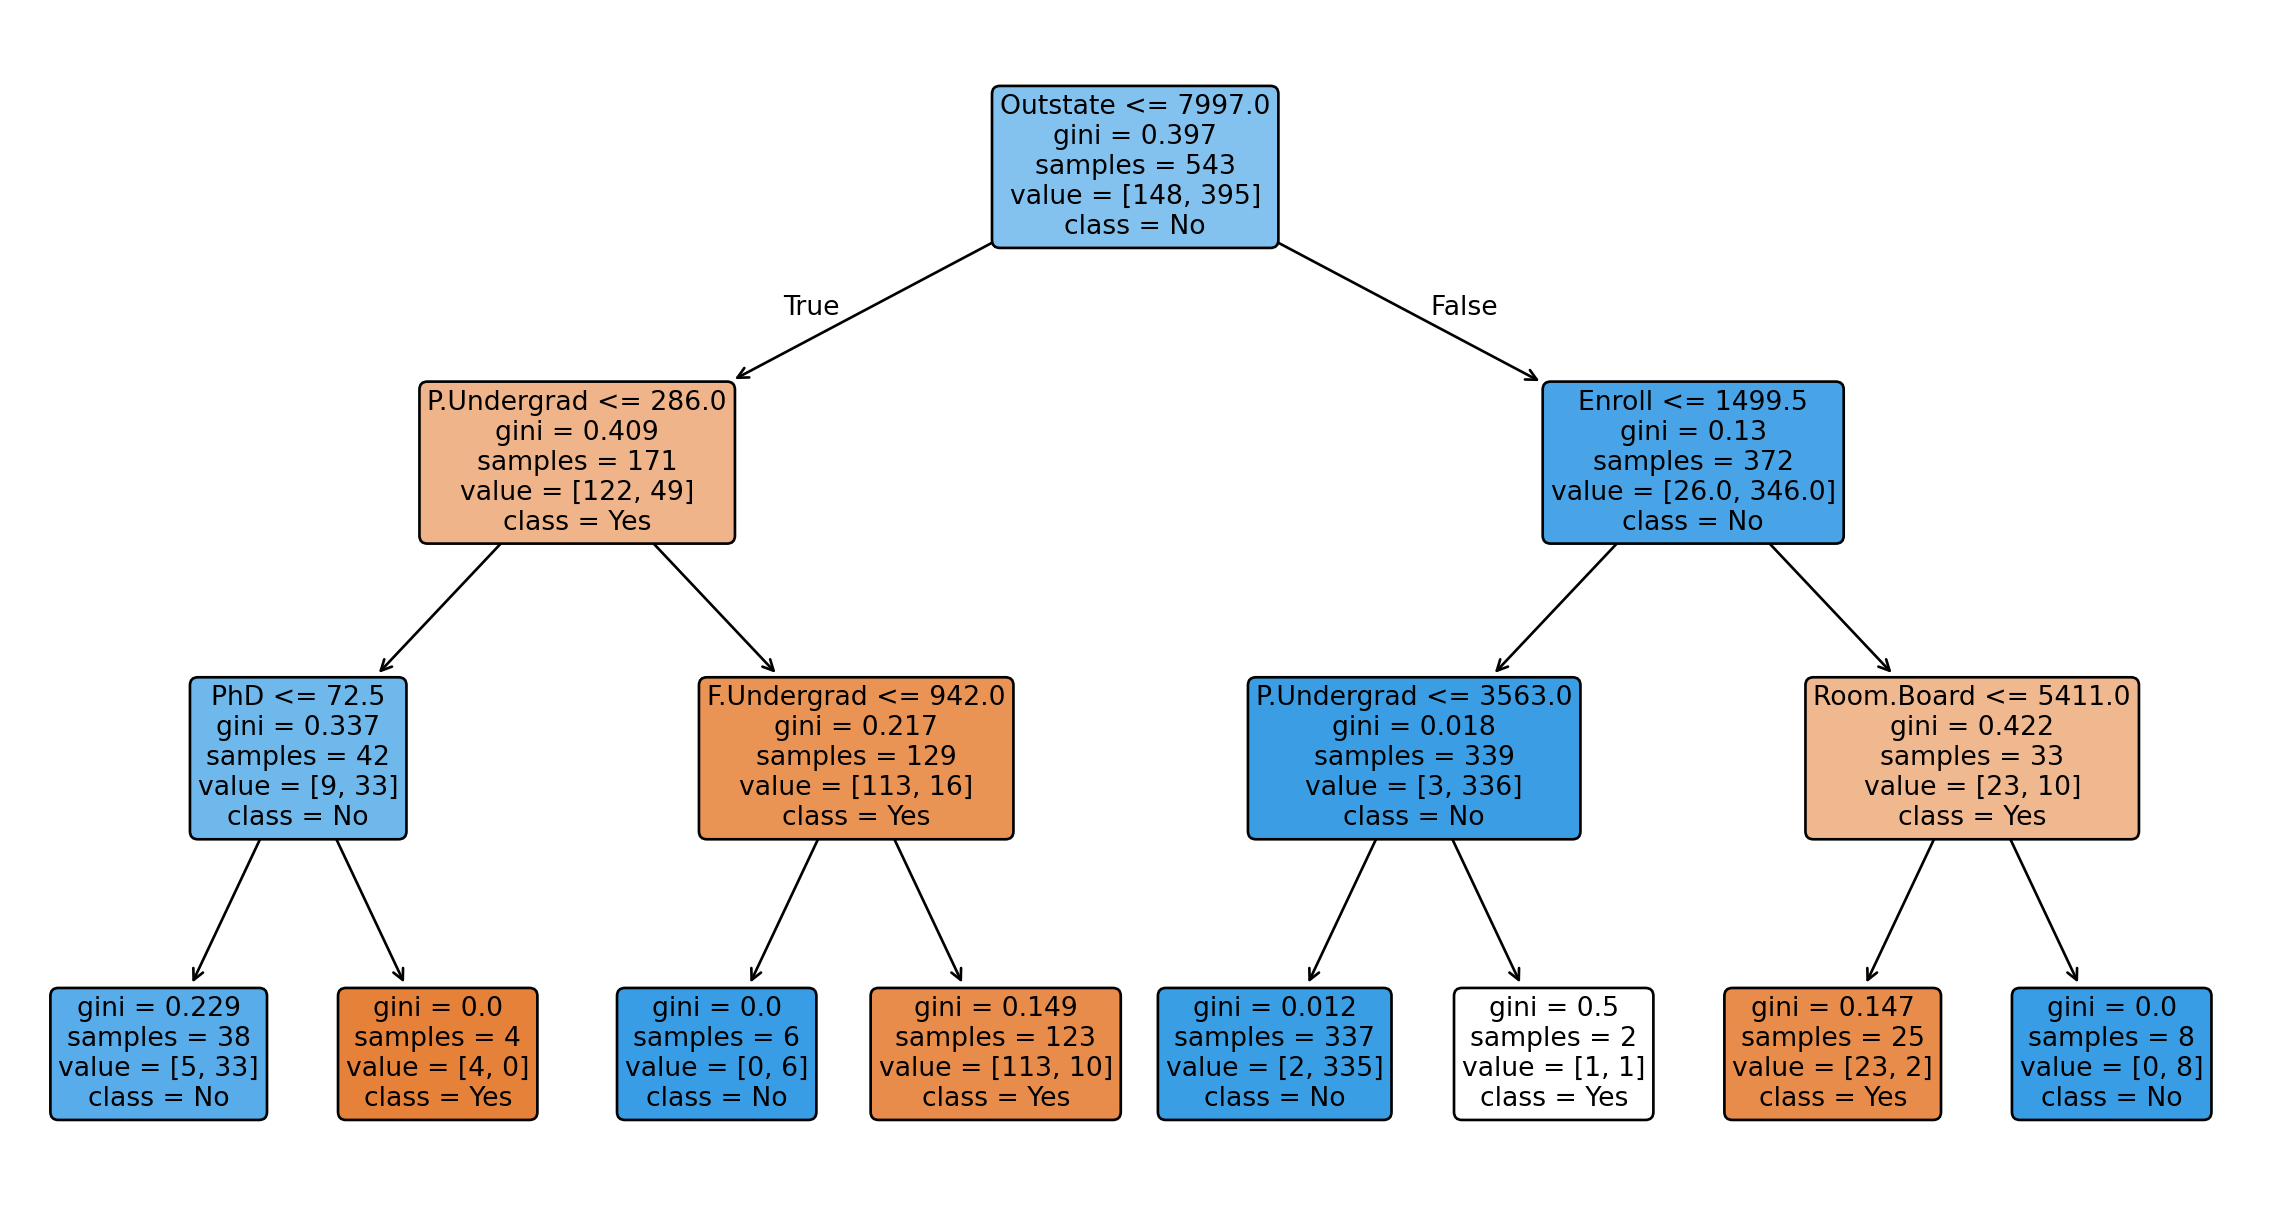

In [19]:
# Visualizando a Árvore de Decisão

# obtendo os nomes das colunas e classes
feature_names = X.columns
class_names = y.unique()

plt.figure(figsize=(15, 8))
plot_tree(clf,
          feature_names=feature_names,  
          class_names=class_names,      
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

In [20]:
balloons = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/balloons.csv")

In [21]:
from sklearn.utils import resample

nova_amostra = resample(
    balloons,  # DataFrame original
    replace=True,  # Permite amostragem com reposição
    random_state=42,  # Seed para reprodutibilidade
    n_samples=len(balloons)  # Tamanho da nova amostra igual ao original
)

# Obtendo os índices únicos que foram selecionados para a nova amostra
indices_in_bag = nova_amostra.index.unique()

# Obtendo os índices do DataFrame original que NÃO estão na lista de `indices_in_bag`
oob_indices = balloons.index.difference(indices_in_bag)

# Usando os índices para selecionar as linhas OOB do DataFrame original
out_of_bag = balloons.loc[oob_indices]

In [22]:
import random

random.seed(414)  # Definindo a semente para reprodutibilidade

# Selecionando aleatoriamente um subconjunto de variáveis para a primeira árvore
variaveis = list(balloons.drop(columns=['inflated']).columns)
variaveis_selecionadas = random.sample(variaveis, k=2)

variaveis_selecionadas

['age', 'size']

In [23]:
pd.crosstab(nova_amostra['size'], nova_amostra['inflated'])

inflated,F,T
size,,
LARGE,4,4
SMALL,3,9


In [24]:
# Calculando o indice de Gini para a variável 'color'
gini_color = (1 - (9/12)**2 - (3/12)**2)*(12/20) + ((1 - 4/8)**2 - (4/8)**2)*(8/20) 

gini_color

0.22499999999999998

In [25]:
pd.crosstab(nova_amostra['age'], nova_amostra['inflated'])

inflated,F,T
age,,
ADULT,2,13
CHILD,5,0


In [26]:
# Calculando o índice de Gini para a variável 'age'
gini_age = (1 - (0/5)**2 - (5/5)**2)*(5/20) + (1 - (13/15)**2 - (2/15)**2)*(15/20)

gini_age

0.17333333333333328

In [27]:
random.seed(42)

# Selecionando aleatoriamente um subconjunto de variáveis para a segunda árvore
variaveis_2 = list(balloons.drop(columns=['inflated', 'color', 'age']).columns)
variaveis_selecionadas_2 = random.sample(variaveis_2, k=2)

variaveis_selecionadas_2

['size', 'act']

In [28]:
pd.crosstab(nova_amostra['size'], nova_amostra['inflated'])

inflated,F,T
size,,
LARGE,4,4
SMALL,3,9


In [29]:
# Calculando o índice de Gini para a variável 'size'
gini_size = (1 - (4/8)**2 - (4/8)**2)*(8/20) + (1 - (3/12)**2 - (9/12)**2)*(12/20)

gini_size

0.425

In [30]:
pd.crosstab(nova_amostra['act'], nova_amostra['inflated'])

inflated,F,T
act,,
DIP,4,0
STRETCH,3,13


In [31]:
# Calculando o índice de Gini para a variável 'act'
gini_act = (1 - (0/4)**2 - (4/4)**2)*(4/20) + (1 - (3/16)**2 - (13/16)**2)*(16/20)

gini_act

0.24375000000000002

In [32]:
out_of_bag

,color,size,act,age,inflated
4,YELLOW,SMALL,DIP,CHILD,F
8,YELLOW,LARGE,DIP,ADULT,F
9,YELLOW,LARGE,DIP,CHILD,F
12,PURPLE,SMALL,STRETCH,CHILD,F
13,PURPLE,SMALL,DIP,ADULT,F
15,PURPLE,LARGE,STRETCH,ADULT,T
17,PURPLE,LARGE,STRETCH,CHILD,F


In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Removendo linhas com valores ausentes
balloons = balloons.dropna()

# A coluna 'inflated' também é convertida para o tipo 'category'
balloons['inflated'] = balloons['inflated'].astype('category')

# Separando a variável alvo (y) das preditoras (X)
X = balloons.drop('inflated', axis=1)
y = balloons['inflated']

# Convertendo as variáveis categóricas em numéricas
X = pd.get_dummies(X)

# Dividindo os dados em 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Construindo a floresta aleatória com 20 árvores
modelo = RandomForestClassifier(n_estimators=20, random_state=2025)

# Treinando o modelo
modelo.fit(X_train, y_train)
previsoes = modelo.predict(X_test)

In [34]:
from sklearn.metrics import classification_report, accuracy_score

# Imprime a acurácia geral
acc = accuracy_score(y_test, previsoes)
print(f"Acurácia do Modelo: {acc:.2f}\n") # Exibe a acurácia com 2 casas decimais

# Imprime o relatório completo
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes))

Acurácia do Modelo: 1.00

Relatório de Classificação:
              precision    recall  f1-score   support

           F       1.00      1.00      1.00         2
           T       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



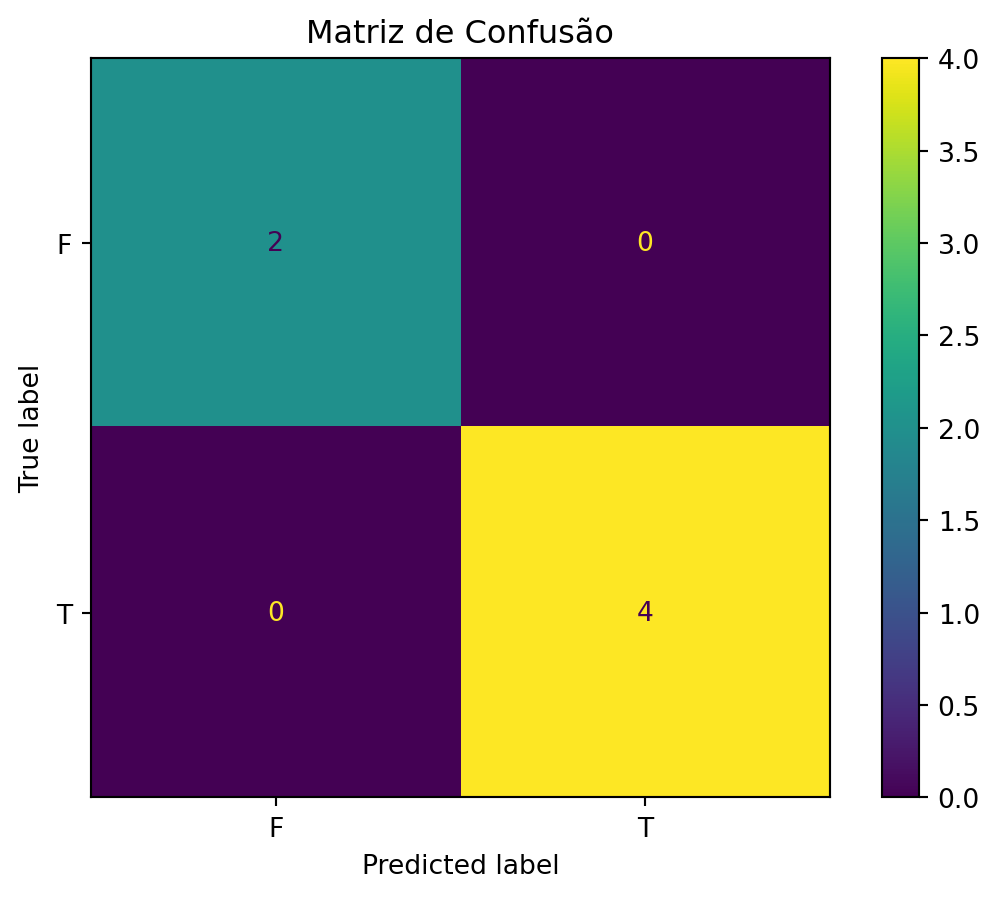

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gera a matriz de confusão
cm = confusion_matrix(y_test, previsoes, labels=modelo.classes_)

# Plota a matriz de confusão de forma gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot()
plt.title("Matriz de Confusão")
plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier

# Construindo a árvore de decisão
modelo_arvore = DecisionTreeClassifier(random_state=2025)

# Treinando o modelo
modelo_arvore.fit(X_train, y_train)
previsoes_arvore = modelo_arvore.predict(X_test)

In [37]:
# Imprime a acurácia geral
acc = accuracy_score(y_test, previsoes_arvore)
print(f"Acurácia do Modelo: {acc:.2f}\n") # Exibe a acurácia com 2 casas decimais

# Imprime o relatório completo
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_arvore))

Acurácia do Modelo: 1.00

Relatório de Classificação:
              precision    recall  f1-score   support

           F       1.00      1.00      1.00         2
           T       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [38]:
golf = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/golf.csv").drop(columns=['Unnamed: 0'])

golf.head()

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes


In [39]:
golf.groupby('Outlook')['Play'].value_counts().sort_index()

Outlook   Play
Overcast  Yes     4
Rain      No      2
          Yes     3
Sunny     No      3
          Yes     2
Name: count, dtype: int64

In [40]:
(4/14) * (1 - (4/4)**2 - (0/4)**2) + (10/14) * (1 - (5/10)**2 - (5/10)**2)

0.35714285714285715

In [41]:
golf.groupby('Humidity')['Play'].value_counts().sort_index()

Humidity  Play
High      No      4
          Yes     3
Normal    No      1
          Yes     6
Name: count, dtype: int64

In [42]:
golf.groupby('Wind')['Play'].value_counts().sort_index()

Wind    Play
Strong  No      3
        Yes     3
Weak    No      2
        Yes     6
Name: count, dtype: int64

In [43]:
golf[(golf['Outlook'] != 'Overcast') & (golf['Play'] != 'No')]

,Outlook,Humidity,Wind,Play
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
8,Sunny,Normal,Weak,Yes
9,Rain,Normal,Weak,Yes
10,Sunny,Normal,Strong,Yes


In [44]:
import numpy as np

amostra = np.arange(1, 15)

pesos = np.repeat(
    a=[0.056, 0.099, 0.056, 0.099, 0.056, 0.057],  # Elementos a serem repetidos
    repeats=[3, 2, 3, 3, 2, 1]                  # Número de vezes que cada elemento é repetido
)

np.random.seed(2025)

resultado_bootstrap = np.random.choice(
    a=amostra,
    size=14,
    replace=True,  # Amostragem com reposição
    p=pesos        # probabilidade de seleção dos elementos
)

print("Amostra original:", amostra)
print("Pesos calculados:", pesos)
print("Resultado do Bootstrap:", resultado_bootstrap)

Amostra original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Pesos calculados: [0.056 0.056 0.056 0.099 0.099 0.056 0.056 0.056 0.099 0.099 0.099 0.056
 0.056 0.057]
Resultado do Bootstrap: [ 3 13 13  7  6  4 10  8 14 11  7 11  1 11]


In [45]:
from sklearn.model_selection import train_test_split

spam = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/spam.csv")

# Separando a amostra em dados de treino e teste
X = spam.drop(columns=['type'])
y = spam['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

In [46]:
from sklearn.ensemble import AdaBoostClassifier

# Criando o classificador AdaBoost
# Por padrão, o estimador base é um DecisionTreeClassifier(max_depth=1)
adaboost_clf = AdaBoostClassifier(n_estimators=100, # Número de estimadores (árvores) a serem usados 
                                   random_state=2025)

# Treinando o modelo
adaboost_clf.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred = adaboost_clf.predict(X_test)

# Avaliando a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo AdaBoost: {accuracy:.4f}")

Acurácia do modelo AdaBoost: 0.9428


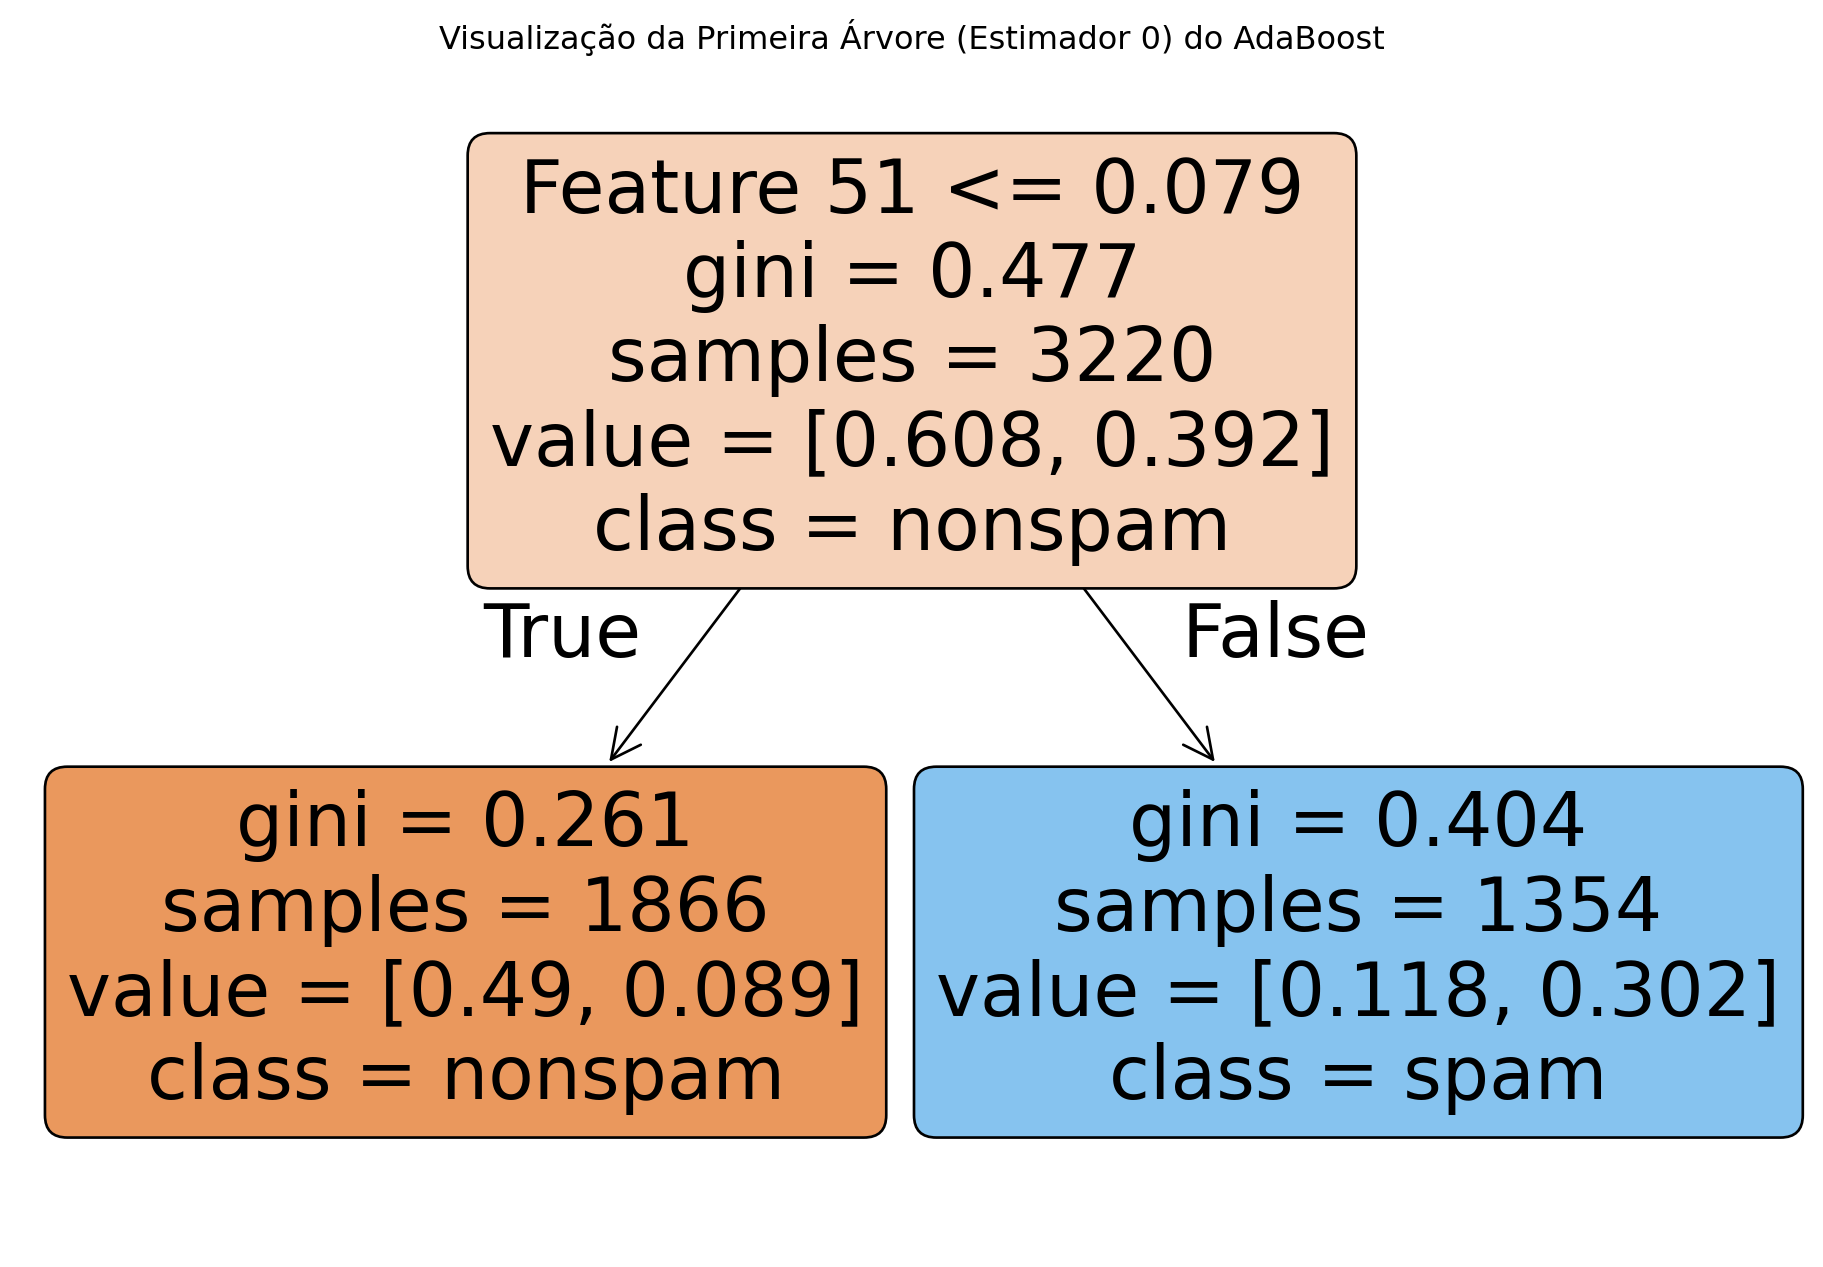

In [47]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Nomes genéricos para as features e classes para uma melhor visualização
feature_names = [f'Feature {i}' for i in range(X.shape[1])]
class_names = [str(c) for c in adaboost_clf.classes_]

# Visualizando a PRIMEIRA árvore (índice 0)
# Esta é a primeira árvore simples que o AdaBoost treinou nos dados originais.
primeira_arvore = adaboost_clf.estimators_[0]

plt.figure(figsize=(12, 8))
plot_tree(primeira_arvore,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True)
plt.title("Visualização da Primeira Árvore (Estimador 0) do AdaBoost")
plt.show()

Text(0.5, 1.0, 'Matriz de Confusão do Modelo AdaBoost')

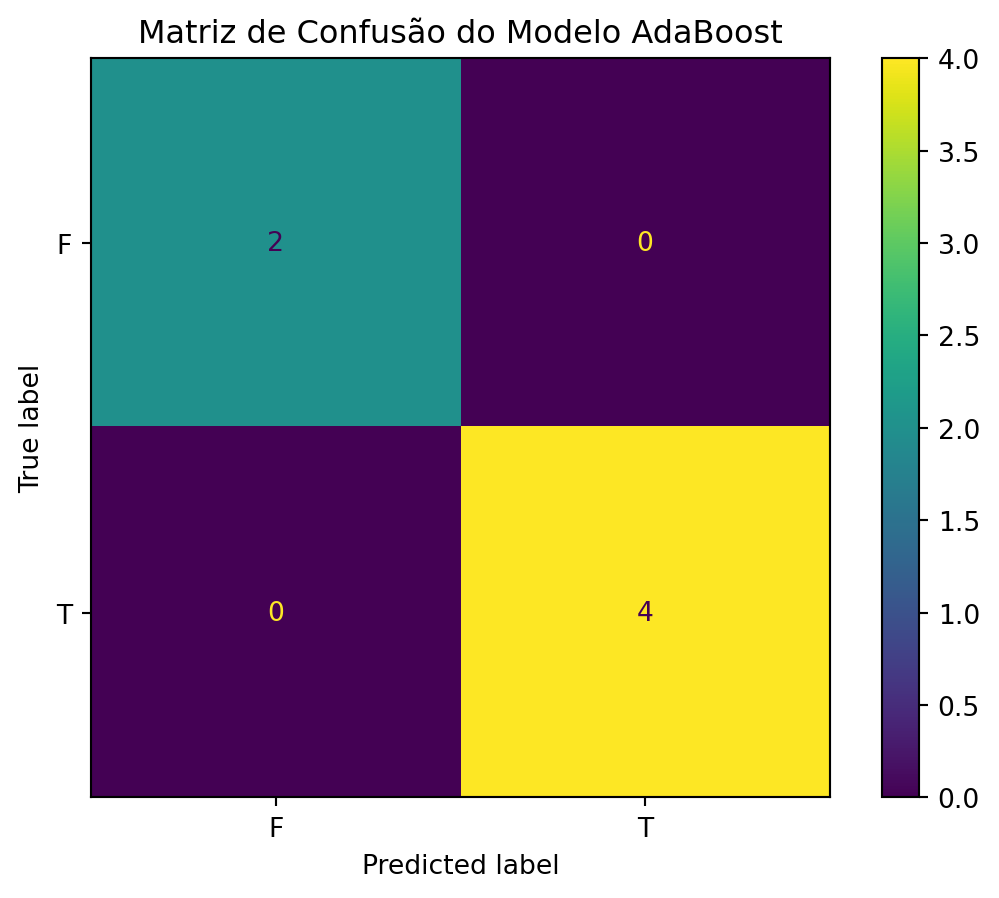

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_ada = confusion_matrix(y_test, y_pred, labels=adaboost_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot()
plt.title("Matriz de Confusão do Modelo AdaBoost")

In [49]:
##   Altura      Cor Sexo Peso
## 1    1.6     Azul    M   88
## 2    1.6    Verde    F   76
## 3    1.5     Azul    F   56
## 4    1.8 Vermelho    M   75
## 5    1.5    Verde    M   77
## 6    1.4     Azul    F   57

In [50]:
##   Altura      Cor Sexo Peso Ps..Res..1
## 1    1.6     Azul    M   88       16.5
## 2    1.6    Verde    F   76        4.5
## 3    1.5     Azul    F   56      -15.5
## 4    1.8 Vermelho    M   75        3.5
## 5    1.5    Verde    M   77        5.5
## 6    1.4     Azul    F   57      -14.5

In [51]:
##   Altura      Cor Sexo Peso Ps..Res..1 Ps..Res..2
## 1    1.6     Azul    M   88       16.5      14.85
## 2    1.6    Verde    F   76        4.5       4.05
## 3    1.5     Azul    F   56      -15.5     -14.00
## 4    1.8 Vermelho    M   75        3.5       3.05
## 5    1.5    Verde    M   77        5.5       5.05
## 6    1.4     Azul    F   57      -14.5     -13.00

In [52]:
import numpy as np # Importar numpy
from sklearn.feature_selection import VarianceThreshold

wage = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/wage.csv").drop(columns=['Unnamed: 0'])

# Selecionar apenas as colunas que são numéricas
wage_numeric = wage.select_dtypes(include=np.number)

# Verificando variáveis de variância zero
selector = VarianceThreshold(threshold=0.2) 
selector.fit_transform(wage_numeric)
colunas_numericas_excluir = wage_numeric.columns[~selector.get_support()]

colunas_numericas_excluir

Index(['logwage'], dtype='object')

In [53]:
# Removendo as colunas de variância zero 
wage.drop(columns=colunas_numericas_excluir, inplace=True)
wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,75.043154


In [54]:
# 2. Separar as variáveis independentes (features, X) e a variável dependente (alvo, y)
X = wage.drop('wage', axis=1)
y = wage['wage']

# A função get_dummies identifica e converte automaticamente as colunas de texto.
# drop_first=True remove a primeira categoria de cada feature para evitar redundância.
X_encoded = pd.get_dummies(X, drop_first=True)

# Dividir os dados em conjuntos de treino e teste (usando os dados já codificados)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=2025)

In [55]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy import sqrt

gbr = GradientBoostingRegressor(
    loss='squared_error',   # Equivalente a distribution="gaussian"
    n_estimators=300,       # Número de árvores
    max_depth=20,           # Profundidade máxima de cada árvore
    random_state=42,
    n_iter_no_change=10,        # Para após 10 iterações sem melhora
    validation_fraction=0.1,    # Usa 10% dos dados de treino como validação
    tol=1e-4
)

#Treinando o modelo
gbr.fit(X_train, y_train)

# Fazendo previsões
y_pred = gbr.predict(X_test)

# Avaliando o modelo
# R-quadrado (R-squared)
r2 = r2_score(y_test, y_pred)

# Erro Absoluto Médio (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Raiz do Erro Quadrático Médio (RMSE)
# Primeiro, calculamos o MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)
# Depois, tiramos a raiz quadrada
rmse = sqrt(mse)

print(f"RMSE      RSquared      MAE")
print(f"{rmse:.2f}     {r2:.2f}         {mae:.2f}")

RMSE      RSquared      MAE
40.87     0.05         28.55


In [56]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2
#   <chr>           <dbl> <chr>          <chr>    
# 1 Sim                12 Azul           Ama      
# 2 Sim                87 Verde          Ama      
# 3 Nao                44 Azul           Odeia    
# 4 Sim                19 Vermelho       Odeia    
# 5 Nao                32 Verde          Ama      
# 6 Nao                14 Azul           Ama

In [57]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2 Ps. Res. 1
#   <chr>           <dbl> <chr>        <chr>       <dbl>
# 1 Sim                12 Azul         Ama         0.3
# 2 Sim                87 Verde        Ama         0.3
# 3 Nao                44 Azul         Odeia       -0.7
# 4 Sim                19 Vermelho     Odeia       -0.7
# 5 Nao                32 Verde        Ama         0.3
# 6 Nao                14 Azul         Ama         0.3

In [58]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2 Ps. Res. 1
#   <chr>           <dbl> <chr>        <chr>       <dbl>
# 1 Sim                12 Azul         Ama         0.9
# 2 Sim                87 Verde        Ama         0.5
# 3 Nao                44 Azul         Odeia       0.5
# 4 Sim                19 Vermelho     Odeia       0.1
# 5 Nao                32 Verde        Ama         0.9
# 6 Nao                14 Azul         Ama         0.9

In [59]:
#   Gosta de Pipoca Idade Cor Favorita Troll 2 Ps. Res. 1
#   <chr>           <dbl> <chr>        <chr>       <dbl>
# 1 Sim                12 Azul         Ama         0.1
# 2 Sim                87 Verde        Ama         0.5
# 3 Nao                44 Azul         Odeia      -0.5
# 4 Sim                19 Vermelho     Odeia      -0.1
# 5 Nao                32 Verde        Ama         0.1
# 6 Nao                14 Azul         Ama         0.1

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

vehicle = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/vehicle.csv")

# Separando a variável alvo (y) das preditoras (X)
X = vehicle.drop(columns=['Class'])
y = vehicle['Class']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Treinando o modelo
gbc = GradientBoostingClassifier(
    n_estimators=100,      # Número de árvores
    max_depth=8,           # Profundidade máxima de cada árvore
    n_iter_no_change=10,   # Para após 10 iterações sem melhora
    validation_fraction=0.1,  # Usa 10% dos dados de treino como
    random_state=100       
)

gbc.fit(X_train, y_train)

# Fazendo previsões
predicao = gbc.predict(X_test)

# Exibindo as 6 primeiras previsões (equivalente ao head())
print(predicao[:6])

['bus' 'van' 'saab' 'opel' 'opel' 'van']


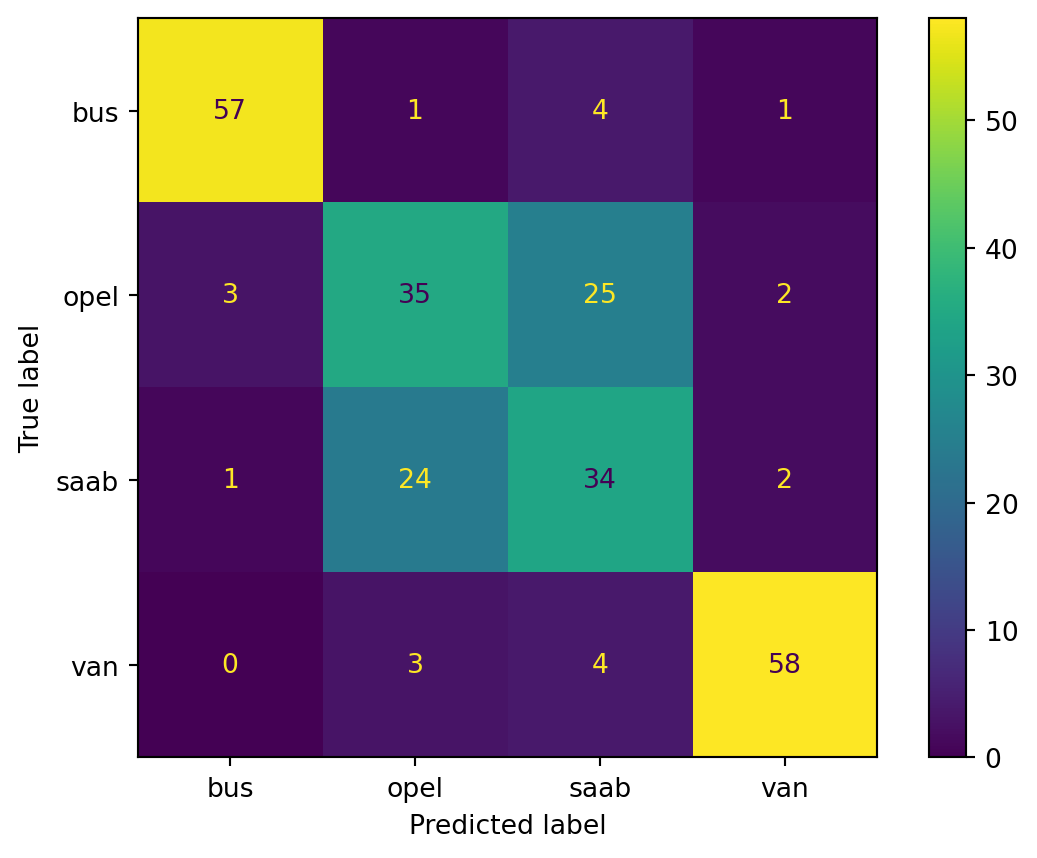

In [61]:
cm_gbc = confusion_matrix(y_test, predicao, labels=gbc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gbc, display_labels=gbc.classes_)
disp.plot()

In [62]:
# acurácia do modelo
accuracy = gbc.score(X_test, y_test)

print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.72


In [63]:
pa = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/peso-altura.csv", sep=';')

pa["residuos"] = pa["Peso"] - 70

In [64]:
nova_pred = (73.6, 73.6, 66.4, 71.5, 66.4)

pa["residuos2"] = pa["Peso"] - nova_pred

pa

,Altura,Peso,residuos,residuos2
0,1.7,88,18,14.4
1,1.6,76,6,2.4
2,1.5,56,-14,-10.4
3,1.8,75,5,3.5
4,1.4,60,-10,-6.4


In [65]:
wine = pd.read_csv("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/winequality-red.csv")

wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [66]:
X = wine.drop(columns=['quality'], axis=1)
y = wine['quality']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

In [67]:
import xgboost as xgb

# Criando o modelo XGBRegressor
xgb_regressor = xgb.XGBRegressor(
    n_estimators=300,  # Número de árvores
    learning_rate=0.3,  # Taxa de aprendizado
    random_state=2025   # Semente para reprodutibilidade
)

# Treinando o modelo
xgb_regressor.fit(X_train, y_train)

# Fazendo previsões
y_pred = xgb_regressor.predict(X_test)

# Avaliando o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}, R-squared: {r2:.2f}, MAE: {mean_absolute_error(y_test, y_pred):.2f}")

RMSE: 0.61, R-squared: 0.38, MAE: 0.40


In [68]:
sc = pd.read_excel("Cadernos Grupo Python/Métodos de Treino Baseados em Árvore/data/SmallCollege.xlsx")

# Vamos adicionar a coluna "Probabilidade" na base de dados que conterá a probabilidade da universidade ser pública:
sc["prob"] = np.where(sc['Private'] == 'Yes', 0, 1)

# Verificando predição inicial
sc["residuos"] = sc['prob'] - 0.5

sc

,Private,Apps,prob,residuos
0,No,2119,1,0.5
1,Yes,1660,0,-0.5
2,Yes,2694,0,-0.5
3,No,2785,1,0.5


In [69]:
ordenados = sc["Apps"].sort_values(ascending=True).head(2).mean()

print(ordenados)

1889.5


In [70]:
sc["residuos2"] = sc["prob"] - [0.5,0.35,0.5,0.65] 

sc

,Private,Apps,prob,residuos,residuos2
0,No,2119,1,0.5,0.50
1,Yes,1660,0,-0.5,-0.35
2,Yes,2694,0,-0.5,-0.50
3,No,2785,1,0.5,0.35


In [71]:
# Nomes das colunas para o dataset "Adult"
colunas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Carregar os dados, definindo os nomes e o marcador de valor ausente
# O .strip() remove espaços em branco extras das colunas
renda = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=colunas,
    na_values=' ?',
    sep=',\s', # O separador é vírgula seguida de espaço
    engine='python'
)

# Para este exemplo, vamos remover as linhas com dados faltantes
renda .dropna(inplace=True)
renda .reset_index(drop=True, inplace=True)
renda .info()

<>:15: SyntaxWarning:

invalid escape sequence '\s'

<>:15: SyntaxWarning:

invalid escape sequence '\s'

C:\Users\dougu\AppData\Local\Temp\ipykernel_2752\34597906.py:15: SyntaxWarning:

invalid escape sequence '\s'



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [72]:
from sklearn.feature_selection import VarianceThreshold

# Selecionar apenas as colunas numéricas
df_numerico = renda.select_dtypes(include='number')

# Selecionar as colunas não numéricas (categóricas) para guardá-las
df_categorico = renda.select_dtypes(exclude='number')

# Inicializar o seletor para remover colunas com variância zero
selector = VarianceThreshold(threshold=1)

# Ajustar o seletor aos dados numéricos
selector.fit(df_numerico)

# Obter as colunas que foram mantidas (com variância > 0)
colunas_mantidas_mask = selector.get_support()
colunas_removidas_mask = ~colunas_mantidas_mask

# Listar as colunas removidas e mantidas
colunas_mantidas = df_numerico.columns[colunas_mantidas_mask].tolist()
colunas_removidas = df_numerico.columns[colunas_removidas_mask].tolist()

if not colunas_removidas:
    print("Nenhuma coluna numérica foi removida. Todas possuem variância maior que zero.")
else:
    print(f"Colunas numéricas removidas: {colunas_removidas}")

# Selecionar apenas as colunas numéricas que passaram no filtro
df_numerico_filtrado = df_numerico[colunas_mantidas]

# Juntar as colunas categóricas originais com as numéricas filtradas
renda_final = pd.concat([df_categorico, df_numerico_filtrado], axis=1)

print(renda_final.head())

Nenhuma coluna numérica foi removida. Todas possuem variância maior que zero.
          workclass  education      marital-status         occupation  \
0         State-gov  Bachelors       Never-married       Adm-clerical   
1  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2           Private    HS-grad            Divorced  Handlers-cleaners   
3           Private       11th  Married-civ-spouse  Handlers-cleaners   
4           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    relationship   race     sex native-country income  age  fnlwgt  \
0  Not-in-family  White    Male  United-States  <=50K   39   77516   
1        Husband  White    Male  United-States  <=50K   50   83311   
2  Not-in-family  White    Male  United-States  <=50K   38  215646   
3        Husband  Black    Male  United-States  <=50K   53  234721   
4           Wife  Black  Female           Cuba  <=50K   28  338409   

   education-num  capital-gain  capital-loss  hours-per-week  

In [73]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separar features (X) e alvo (y)
X = renda_final.drop('income', axis=1)
y = renda_final['income']

# Codificar a variável alvo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Converter as colunas de features para o tipo 'category'
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Criar e treinar o modelo com suporte nativo para categorias
# 🚀 O passo chave está aqui!
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    enable_categorical=True  # Habilita o superpoder para categorias!
)

xgb_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = xgb_model.predict(X_test)

# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do Modelo: {accuracy:.4f}")

# Exibir um relatório de classificação mais detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))      


Acurácia do Modelo: 0.8717

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7417
           1       0.77      0.67      0.71      2352

    accuracy                           0.87      9769
   macro avg       0.83      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769

